<a href="https://colab.research.google.com/github/Kiransai2509/Post-Disaster-Damage-Assessment/blob/main/PDDA_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import cv2
from shapely import wkt
from google.colab import drive


base_path = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/'

image_path = base_path + 'images/guatemala-volcano_00000000_post_disaster.png'
json_path = base_path + 'labels/guatemala-volcano_00000000_post_disaster.json'

out_damaged = base_path + 'Model_Data/Damaged/'
out_undamaged = base_path + 'Model_Data/Undamaged/'

os.makedirs(out_damaged, exist_ok=True)
os.makedirs(out_undamaged, exist_ok=True)

print("Loading files from your project folder...")
image = cv2.imread(image_path)
with open(json_path, 'r') as f:
    label_data = json.load(f)

buildings = label_data['features']['xy']
print(f"Found {len(buildings)} buildings. Starting extraction...")

saved_count = 0
error_count = 0

for i, building in enumerate(buildings):
    try:
        damage_status = building['properties']['subtype']

        if damage_status == 'no-damage':
            save_folder = out_undamaged
            prefix = "safe_"
        elif damage_status in ['minor-damage', 'major-damage', 'destroyed']:
            save_folder = out_damaged
            prefix = "dmg_"
        else:
            continue

        polygon_text = building['wkt']
        building_shape = wkt.loads(polygon_text)
        minx, miny, maxx, maxy = building_shape.bounds

        pad = 10
        crop = image[int(miny)-pad : int(maxy)+pad, int(minx)-pad : int(maxx)+pad]

        filename = f"{save_folder}{prefix}bldg_{i}.png"
        success = cv2.imwrite(filename, crop)

        if success:
            saved_count += 1
        else:
            print(f"Failed to save {filename}. Check if the path is perfectly correct.")

    except KeyError as e:
        if error_count == 0:
            print(f"CRITICAL ERROR: Missing JSON key {e}. Ensure you are using the post_disaster.json file.")
        error_count += 1
    except Exception as e:
        error_count += 1

print(f"\n--- EXTRACTION REPORT ---")
print(f"Successfully saved: {saved_count} images.")
print(f"Errors/Skipped: {error_count} buildings.")

# Force Drive to Sync
drive.flush_and_unmount()
print("Forced Google Drive to sync. Please refresh your Drive tab!")

Mounted at /content/drive
Loading files from your project folder...
Found 10 buildings. Starting extraction...

--- EXTRACTION REPORT ---
Successfully saved: 9 images.
Errors/Skipped: 1 buildings.
Forced Google Drive to sync. Please refresh your Drive tab!


In [ ]:
import os
import json
import cv2
import glob
from shapely import wkt
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/'
out_damaged = base_path + 'Model_Data/Damaged/'
out_undamaged = base_path + 'Model_Data/Undamaged/'

os.makedirs(out_damaged, exist_ok=True)
os.makedirs(out_undamaged, exist_ok=True)

search_path = base_path + 'labels/*_post_disaster.json'
all_json_files = glob.glob(search_path)

print(f"Found {len(all_json_files)} post-disaster JSON files in your folder!")

LIMIT = 50
json_files_to_process = all_json_files[:LIMIT]

saved_count = 0
error_count = 0

print(f"\nStarting mass extraction for {LIMIT} images... This might take a few minutes.")

for current_idx, json_path in enumerate(json_files_to_process):
    image_path = json_path.replace('labels', 'images').replace('.json', '.png')

    if not os.path.exists(image_path):
        continue

    image = cv2.imread(image_path)
    with open(json_path, 'r') as f:
        label_data = json.load(f)

    if 'xy' not in label_data['features']:
        continue

    buildings = label_data['features']['xy']

    for i, building in enumerate(buildings):
        try:
            damage_status = building['properties']['subtype']
            if damage_status == 'no-damage':
                save_folder = out_undamaged
                prefix = "safe_"
            elif damage_status in ['minor-damage', 'major-damage', 'destroyed']:
                save_folder = out_damaged
                prefix = "dmg_"
            else:
                continue # Skip unclassified buildings

            building_shape = wkt.loads(building['wkt'])
            minx, miny, maxx, maxy = building_shape.bounds

            pad = 10
            crop = image[int(miny)-pad : int(maxy)+pad, int(minx)-pad : int(maxx)+pad]

            base_filename = os.path.basename(image_path).replace('.png', '')
            filename = f"{save_folder}{prefix}{base_filename}_bldg_{i}.png"

            if cv2.imwrite(filename, crop):
                saved_count += 1
            else:
                error_count += 1
        except Exception as e:
            error_count += 1

    if (current_idx + 1) % 10 == 0:
        print(f"Processed {current_idx + 1}/{LIMIT} satellite images... Total building crops saved so far: {saved_count}")

print(f"\n--- MASS EXTRACTION COMPLETE ---")
print(f"Successfully saved: {saved_count} cropped buildings.")
print(f"Skipped/Errors: {error_count} buildings.")

drive.flush_and_unmount()

Mounted at /content/drive
Found 2799 post-disaster JSON files in your folder!

Starting mass extraction for 50 images... This might take a few minutes.
Processed 10/50 satellite images... Total building crops saved so far: 62
Processed 20/50 satellite images... Total building crops saved so far: 103
Processed 30/50 satellite images... Total building crops saved so far: 351
Processed 40/50 satellite images... Total building crops saved so far: 543
Processed 50/50 satellite images... Total building crops saved so far: 814

--- MASS EXTRACTION COMPLETE ---
Successfully saved: 814 cropped buildings.
Skipped/Errors: 76 buildings.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("WARNING: GPU is not enabled! Training will be extremely slow.")

data_dir = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/Model_Data/'

data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Add some rotation to make the model robust
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ResNet normalization
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

print("Downloading pre-trained ResNet18...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

weights = 1.0 / class_counts.float()
weights = weights / weights.sum() # Normalize weights
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n--- NEURAL NETWORK READY ---")
print("Model, Loss Function, and Optimizer successfully configured on the GPU.")

Using device: cuda
Loaded 658 training images and 165 validation images.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]



--- NEURAL NETWORK READY ---
Model, Loss Function, and Optimizer successfully configured on the GPU.


In [ ]:
import time
from sklearn.metrics import f1_score
import numpy as np

epochs = 5

print("🚀 Starting the Training Loop...\n")

for epoch in range(epochs):
    start_time = time.time()

    # 1. TRAINING PHASE

    model.train() # Tell the model it is time to learn
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Send data to GPU

        optimizer.zero_grad() # Clear out old memory from the last batch

        outputs = model(inputs) # The model makes its guesses
        loss = criterion(outputs, labels) # We grade the guesses

        loss.backward() # The math to figure out the mistakes
        optimizer.step() # The model updates its brain!

        running_loss += loss.item()

        # Track training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # 2. VALIDATION PHASE (The Test)
    model.eval() # Tell the model to stop learning and take a test on unseen data
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    all_preds = []
    all_targets = []

    with torch.no_grad(): # Don't track gradients during the test (saves memory)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Save predictions to calculate our F1 Score
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    val_acc = 100 * correct_val / total_val
    val_f1 = f1_score(all_targets, all_preds, average='macro')

    end_time = time.time()

    # 3. PRINT THE REPORT CARD
    print(f"Epoch {epoch+1}/{epochs} | Time: {end_time - start_time:.0f} seconds")
    print(f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss/len(val_loader):.4f} | Val Acc:   {val_acc:.2f}% | Val F1: {val_f1:.4f}\n")

print("🎉 Training Complete!")

🚀 Starting the Training Loop...

Epoch 1/5 | Time: 8 seconds
Train Loss: 0.7248 | Train Acc: 73.10%
Val Loss:   24.0060 | Val Acc:   90.91% | Val F1: 0.5349

Epoch 2/5 | Time: 5 seconds
Train Loss: 0.2928 | Train Acc: 88.91%
Val Loss:   1.6799 | Val Acc:   94.55% | Val F1: 0.8398

Epoch 3/5 | Time: 4 seconds
Train Loss: 0.2327 | Train Acc: 92.55%
Val Loss:   1.1404 | Val Acc:   92.12% | Val F1: 0.8021

Epoch 4/5 | Time: 4 seconds
Train Loss: 0.1970 | Train Acc: 88.91%
Val Loss:   0.6759 | Val Acc:   90.30% | Val F1: 0.7621

Epoch 5/5 | Time: 5 seconds
Train Loss: 0.1961 | Train Acc: 91.34%
Val Loss:   0.3419 | Val Acc:   78.18% | Val F1: 0.6591

🎉 Training Complete!


In [ ]:
import torch
import os

save_dir = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/'

model_name = 'resnet18_damage_assessment_v1.pth'
save_path = os.path.join(save_dir, model_name)

print(f"Saving model weights to: {save_path} ...")
torch.save(model.state_dict(), save_path)

print("✅ Model successfully saved to Google Drive!")

Saving model weights to: /content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/resnet18_damage_assessment_v1.pth ...
✅ Model successfully saved to Google Drive!


Loading your trained model...
Loading satellite map...
Found 10 buildings. Running AI predictions...

--- AI ASSESSMENT COMPLETE ---
Buildings assessed as DAMAGED: 1
Buildings assessed as SAFE: 9


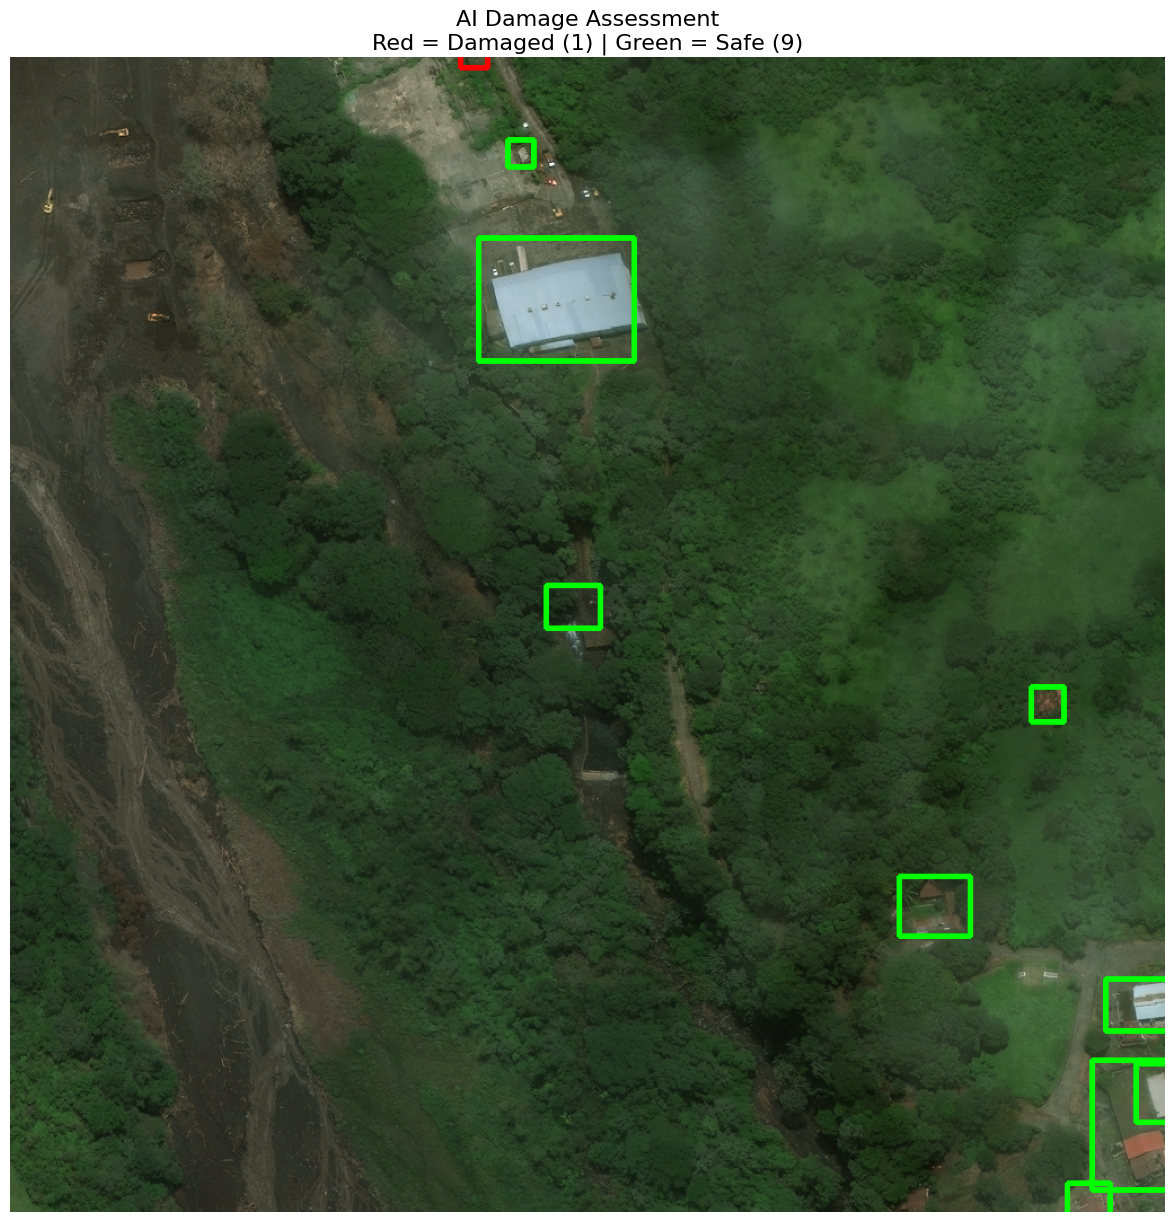

In [ ]:
import os
import cv2
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from shapely import wkt
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_path = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/'
model_path = os.path.join(base_path, 'resnet18_damage_assessment_v1.pth')

test_image_path = base_path + 'images/guatemala-volcano_00000000_post_disaster.png'
test_json_path = base_path + 'labels/guatemala-volcano_00000000_post_disaster.json'

print("Loading your trained model...")
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 2) # 2 classes (Damaged, Undamaged)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval() # Tell the model we are testing, not training!

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Loading satellite map...")
original_image = cv2.imread(test_image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB) # Fix colors for plotting

with open(test_json_path, 'r') as f:
    label_data = json.load(f)

buildings = label_data['features']['xy']
print(f"Found {len(buildings)} buildings. Running AI predictions...\n")

damaged_count = 0
safe_count = 0

for building in buildings:
    try:
        polygon_text = building['wkt']
        building_shape = wkt.loads(polygon_text)
        minx, miny, maxx, maxy = building_shape.bounds

        pad = 5
        crop_array = original_image[int(miny)-pad : int(maxy)+pad, int(minx)-pad : int(maxx)+pad]

        crop_pil = Image.fromarray(crop_array)
        input_tensor = test_transforms(crop_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
            prediction = predicted.item()

        start_point = (int(minx)-pad, int(miny)-pad)
        end_point = (int(maxx)+pad, int(maxy)+pad)
        thickness = 3

        if prediction == 0: # Damaged
            color = (255, 0, 0) # RED
            damaged_count += 1
        else:               # Undamaged
            color = (0, 255, 0) # GREEN
            safe_count += 1

        # Draw the rectangle directly onto the massive original image
        cv2.rectangle(original_image, start_point, end_point, color, thickness)

    except Exception as e:
        continue # Skip if building is off the edge of the map

# 6. Display the Final Result!
print(f"--- AI ASSESSMENT COMPLETE ---")
print(f"Buildings assessed as DAMAGED: {damaged_count}")
print(f"Buildings assessed as SAFE: {safe_count}")

plt.figure(figsize=(15, 15))
plt.imshow(original_image)
plt.title(f"AI Damage Assessment\nRed = Damaged ({damaged_count}) | Green = Safe ({safe_count})", fontsize=16)
plt.axis('off')
plt.show()

Loading your trained model...
Searching your dataset for an image with heavy damage...
Found Impact Zone! Testing on: socal-fire_00000472_post_disaster.png

--- AI ASSESSMENT COMPLETE ---
Buildings assessed as DAMAGED (Red): 8
Buildings assessed as SAFE (Green): 22


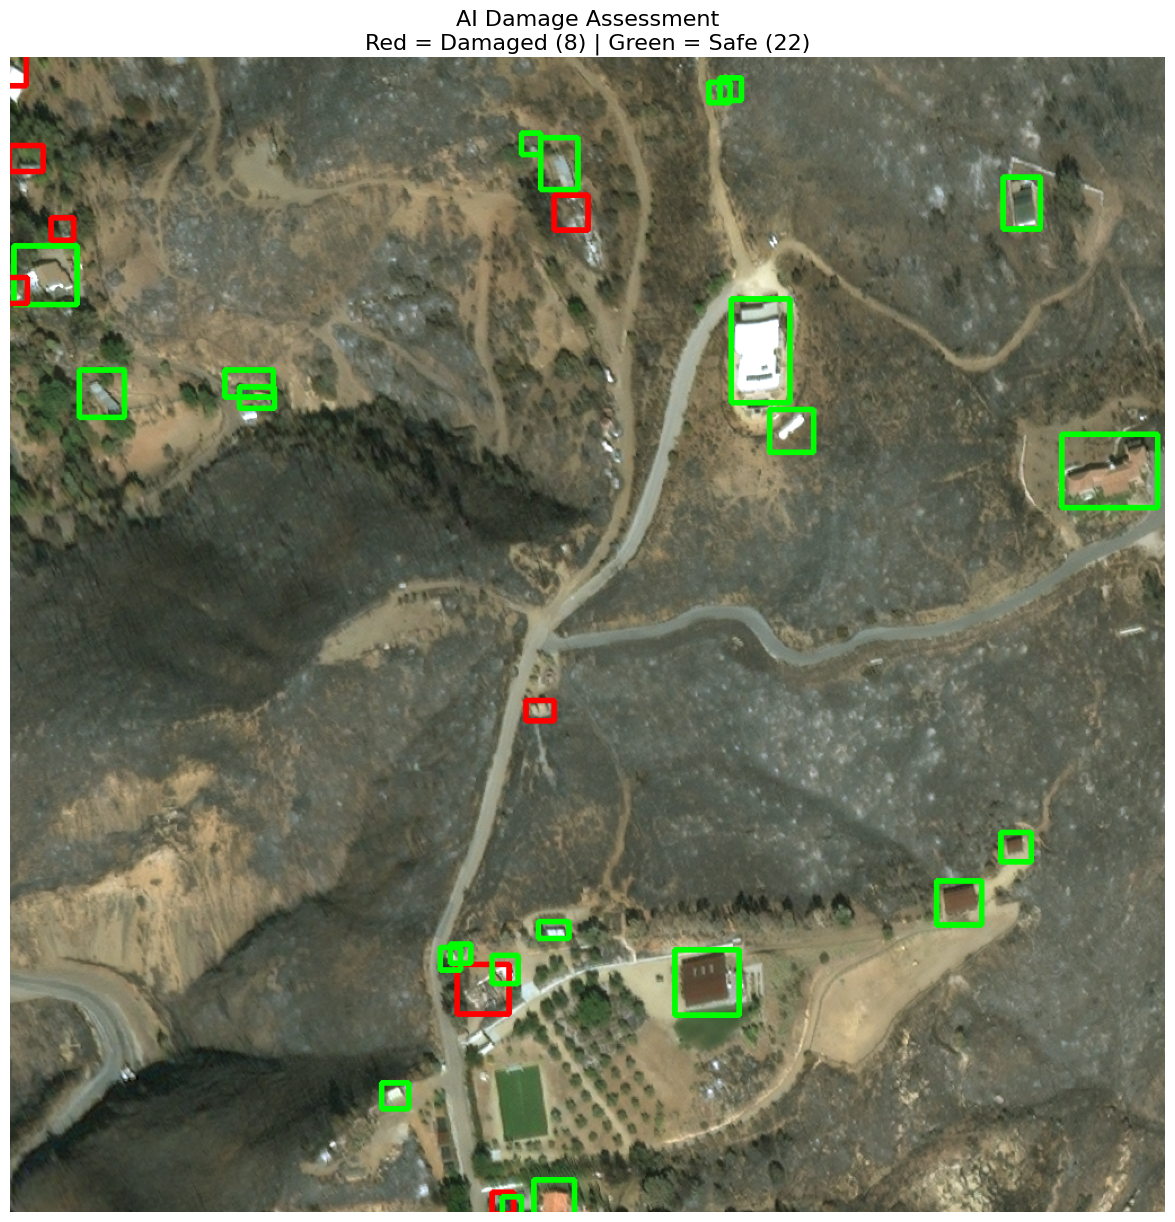

In [ ]:
import os
import cv2
import json
import glob
import torch
import torch.nn as nn
from torchvision import models, transforms
from shapely import wkt
import matplotlib.pyplot as plt
from PIL import Image

# 1. Setup Device and Paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_path = '/content/drive/MyDrive/Post-Disaster Damage Assessment(ML Project)/'
model_path = os.path.join(base_path, 'resnet18_damage_assessment_v1.pth')

# 2. Rebuild the Model Architecture and Load Your Saved Brain
print("Loading your trained model...")
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# 3. Setup the Image Transformations
test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. HUNT FOR THE IMPACT ZONE
print("Searching your dataset for an image with heavy damage...")
search_path = base_path + 'labels/*_post_disaster.json'
all_json_files = glob.glob(search_path)

target_json = None
target_image = None

for json_path in all_json_files:
    with open(json_path, 'r') as f:
        data = json.load(f)
        if 'xy' in data['features']:
            # Look through the buildings to find one that is destroyed
            for building in data['features']['xy']:
                if building['properties']['subtype'] in ['destroyed', 'major-damage']:
                    target_json = json_path
                    target_image = json_path.replace('labels', 'images').replace('.json', '.png')
                    break # We found one!
    if target_json:
        break

if not target_image or not os.path.exists(target_image):
    print("Could not find an image with heavy damage. Check your dataset!")
else:
    print(f"Found Impact Zone! Testing on: {os.path.basename(target_image)}\n")

    # 5. Load the Canvas and Run Inference
    original_image = cv2.imread(target_image)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    with open(target_json, 'r') as f:
        label_data = json.load(f)

    buildings = label_data['features']['xy']

    damaged_count = 0
    safe_count = 0

    for building in buildings:
        try:
            polygon_text = building['wkt']
            building_shape = wkt.loads(polygon_text)
            minx, miny, maxx, maxy = building_shape.bounds

            pad = 5
            crop_array = original_image[int(miny)-pad : int(maxy)+pad, int(minx)-pad : int(maxx)+pad]
            crop_pil = Image.fromarray(crop_array)
            input_tensor = test_transforms(crop_pil).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                _, predicted = torch.max(output, 1)
                prediction = predicted.item()

            # Draw Boxes
            start_point = (int(minx)-pad, int(miny)-pad)
            end_point = (int(maxx)+pad, int(maxy)+pad)
            thickness = 3

            if prediction == 0:
                color = (255, 0, 0) # RED for Damaged
                damaged_count += 1
            else:
                color = (0, 255, 0) # GREEN for Safe
                safe_count += 1

            cv2.rectangle(original_image, start_point, end_point, color, thickness)

        except Exception as e:
            continue

    print(f"--- AI ASSESSMENT COMPLETE ---")
    print(f"Buildings assessed as DAMAGED (Red): {damaged_count}")
    print(f"Buildings assessed as SAFE (Green): {safe_count}")

    plt.figure(figsize=(15, 15))
    plt.imshow(original_image)
    plt.title(f"AI Damage Assessment\nRed = Damaged ({damaged_count}) | Green = Safe ({safe_count})", fontsize=16)
    plt.axis('off')
    plt.show()